# 07. 리밸런싱 간격별 강건성 검증 (30일/252일)
지금까지 60일/120일 두 간격만 검증했다. 나머지 두 간격(30일, 252일)에도 똑같은 파이프라인(군집화 → 성과 검증 → Sharpe)을 적용해서, "안정성 우선" 전략의 결과가 리밸런싱 간격에 상관없이 일관된지(강건한지) 확인한다.

60일/120일에서는 시장 국면(베타 노출)이 결과를 좌우한다는 걸 확인했으므로, 이번에도 같은 잣대로 해석한다.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path('/Users/choedasom/lab_middle_project')
assert (PROJECT_ROOT / 'src' / 'performance.py').is_file(), f'경로 확인 필요: {PROJECT_ROOT}'
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

for m in list(sys.modules):
    if m == 'src' or m.startswith('src.'):
        del sys.modules[m]

import pandas as pd
from src.feature import add_features
from src.get_tickers import filter_by_membership
from src.cluster import cluster_all_snapshots
from src.performance import add_forward_returns, summarize_by_group, overall_stats, risk_adjusted_stats, sharpe_ratio_stats

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
final_df = pd.read_parquet(PROCESSED_DIR / 'final_df.parquet')
# 2026-09-02: 벤치마크 비교는 총수익지수(^SP500TR) 기준 -- 개별 종목이 이미
# 배당조정가라 ^GSPC(가격지수)와 비교하면 배당수익률만큼 벤치마크가 과소평가됨.
# 변수명은 sp500_beta_df 그대로 두되(다운스트림 코드 최소 변경), 내용물은 총수익지수.
sp500_beta_df = pd.read_parquet(RAW_DIR / 'sp500_total_return_df.parquet')
print(f'final_df: {final_df.shape}')

final_df: (1661688, 8)


## 30일/252일 피처 생성 및 리밸런싱 스냅샷 구성
60일/120일 때와 동일한 절차: `add_features()` → 리밸런싱 간격으로 샘플링 → `filter_by_membership()`으로 시점별 자격 필터.

In [2]:
featured = add_features(final_df, sp500_beta_df=sp500_beta_df, windows=(30, 252))
print(f'featured: {featured.shape}, 컬럼: {[c for c in featured.columns if "_30d" in c or "_252d" in c]}')

rebalance_dfs = {}
for window in (30, 252):
    feature_cols = [f'{m}_{window}d' for m in ['beta', 'volatility', 'return', 'rsi']]
    cluster_df = featured[['Date', 'Ticker', *feature_cols]].copy()

    all_dates = sorted(cluster_df['Date'].unique())
    rebalance_dates = all_dates[::window]
    snapshots = cluster_df[cluster_df['Date'].isin(rebalance_dates)].copy()
    rebalance_df = filter_by_membership(snapshots)
    rebalance_df.to_parquet(PROCESSED_DIR / f'rebalance_{window}df.parquet', index=False)
    rebalance_dfs[window] = rebalance_df

    print(f'[{window}일] 전체 거래일 {len(all_dates)}, 리밸런싱 시점 {len(rebalance_dates)}개 -> '
          f'필터 후 {rebalance_df["Date"].nunique()}개 시점, {rebalance_df["Ticker"].nunique()}종목')

[경고] |일간수익률| > 75% 인 행 47건 / 12종목 → NaN 마스킹
      Date Ticker     Close  daily_return
2024-03-12   SIVB  0.110000     83.615385
2024-03-06   SIVB  0.070000     52.846154
2024-10-04    CHK 81.460000     25.708197
2026-06-04    STI 22.709999      3.505952
2023-11-09   SIVB  0.080000      3.000000
2025-10-13    STI 21.625000      2.938980
2023-11-16   SIVB  0.030000      2.000000
2023-09-19   SIVB  0.145000      1.900000
2024-01-10   SIVB  0.200000      1.857143
2020-06-08    CHK 69.920000      1.819355
        find_price_anomalies()로 원본 가격을 확인하세요 (price_range_ratio > 1000 이면 분할 미조정 의심).


[경고] |beta_30d| > 20.0 인 행 4건 / 1종목 → NaN 마스킹 (수익률 마스킹 후에도 남았다면 데이터 문제가 더 있습니다)
      Date Ticker       beta
2024-07-18   SIVB -28.160380
2024-07-19   SIVB -23.192674
2024-07-22   SIVB -21.131080
2024-07-23   SIVB -21.048913


[경고] |return_30d| > 10 인 행 10건 / 3종목 → NaN 마스킹


[경고] |return_252d| > 10 인 행 420건 / 12종목 → NaN 마스킹
[요약] 피처별 유효값 비율
beta_252d          0.8922
beta_30d           0.9867
return_252d        0.8941
return_30d         0.9872
rsi_252d           0.8922
rsi_30d            0.9867
volatility_252d    0.8922
volatility_30d     0.9867
featured: (1661688, 16), 컬럼: ['volatility_30d', 'beta_30d', 'rsi_30d', 'return_30d', 'volatility_252d', 'beta_252d', 'rsi_252d', 'return_252d']
[캐시] 편입/편출 이력 1259건 재사용 (/Users/choedasom/lab_middle_project/data/raw/cache/sp500_membership_history.csv)
[INFO] 시점별 자격 미달로 제외된 (종목,날짜) 조합: 12373건 / 55457건
[30일] 전체 거래일 2637, 리밸런싱 시점 88개 -> 필터 후 88개 시점, 682종목


[캐시] 편입/편출 이력 1259건 재사용 (/Users/choedasom/lab_middle_project/data/raw/cache/sp500_membership_history.csv)
[INFO] 시점별 자격 미달로 제외된 (종목,날짜) 조합: 1558건 / 6928건
[252일] 전체 거래일 2637, 리밸런싱 시점 11개 -> 필터 후 11개 시점, 671종목


## 군집화 (k=2) 및 성과 검증

In [3]:
clustered_dfs = {}
perf_dfs = {}
summary_dfs = {}

for window in (30, 252):
    clustered = cluster_all_snapshots(rebalance_dfs[window], window=window, n_clusters=2, stability_weight=2.0)
    clustered.to_parquet(PROCESSED_DIR / f'clustered_{window}df.parquet', index=False)
    clustered_dfs[window] = clustered

    perf = add_forward_returns(clustered, final_df)
    perf_dfs[window] = perf
    summary_dfs[window] = summarize_by_group(perf)

    print(f'=== {window}일 ===')
    print(overall_stats(summary_dfs[window]))
    print()
    print(risk_adjusted_stats(perf))
    print()
    print(sharpe_ratio_stats(perf, window=window, annual_risk_free_rate=0.02))
    print()

[캐시] 편입/편출 이력 1259건 재사용 (/Users/choedasom/lab_middle_project/data/raw/cache/sp500_membership_history.csv)


=== 30일 ===
n_snapshots               86.000000
stable_mean_return         0.015432
other_mean_return          0.021098
avg_stable_minus_other    -0.005666
win_rate                   0.441860
dtype: float64

                   n      mean       std  return_per_risk
stable_cluster  86.0  0.015432  0.045627         0.338210
other_clusters  86.0  0.021098  0.080233         0.262957

                   n      mean       std  excess_mean  sharpe_annualized
stable_cluster  86.0  0.015432  0.045627     0.013071           0.830302
other_clusters  86.0  0.021098  0.080233     0.018738           0.676864



[캐시] 편입/편출 이력 1259건 재사용 (/Users/choedasom/lab_middle_project/data/raw/cache/sp500_membership_history.csv)


=== 252일 ===
n_snapshots               9.000000
stable_mean_return        0.101435
other_mean_return         0.134200
avg_stable_minus_other   -0.032765
win_rate                  0.444444
dtype: float64

                  n      mean       std  return_per_risk
stable_cluster  9.0  0.101435  0.121338         0.835970
other_clusters  9.0  0.134200  0.158019         0.849262

                  n      mean       std  excess_mean  sharpe_annualized
stable_cluster  9.0  0.101435  0.121338     0.081435           0.671141
other_clusters  9.0  0.134200  0.158019     0.114200           0.722695



## 시장 국면과의 상관관계 (60일/120일과 동일한 방식)

In [4]:
def market_forward_return(dates, prices):
    """전략(add_forward_returns)과 동일한 T+1 진입/청산 관례를 쓴다
    (2026-09-02 fix). 신호를 관찰한 날(T)의 종가로 그 자리에서 바로 매매하는
    건 비현실적이라 전략 쪽 entry/exit를 각각 다음 거래일로 한 칸씩 미뤘는데,
    이 벤치마크 함수만 안 미뤄져 있으면 stable_minus_other와 날짜 정렬 자체가
    어긋난 채로 상관계수를 계산하게 된다 (notebooks/10_full_backtest.ipynb의
    market_returns_like()와 동일한 관례).
    """
    trading_dates = sorted(prices['Date'].unique())
    next_trading_day = dict(zip(trading_dates[:-1], trading_dates[1:]))

    dates = sorted(dates)
    next_date_map = dict(zip(dates[:-1], dates[1:]))
    close = prices.set_index('Date')['Close']
    out = {}
    for d, nd in next_date_map.items():
        entry_date = next_trading_day.get(d)
        exit_date = next_trading_day.get(nd)
        if entry_date in close.index and exit_date in close.index:
            out[d] = close[exit_date] / close[entry_date] - 1.0
    return pd.Series(out, name='market_return')

market_corr = {}
for window in (30, 252):
    mkt = market_forward_return(summary_dfs[window].index.tolist(), sp500_beta_df)
    corr = summary_dfs[window]['stable_minus_other'].corr(mkt)
    market_corr[window] = corr
    print(f'{window}일: 안정-나머지 격차와 시장수익률 상관계수 = {corr:.3f}')

30일: 안정-나머지 격차와 시장수익률 상관계수 = -0.669
252일: 안정-나머지 격차와 시장수익률 상관계수 = -0.572


## 4개 리밸런싱 간격 전체 비교

In [5]:
rows = []
for window in (30, 60, 120, 252):
    if window in (30, 252):
        perf = perf_dfs[window]
        summary = summary_dfs[window]
    else:
        clustered = pd.read_parquet(PROCESSED_DIR / f'clustered_{window}df.parquet')
        perf = add_forward_returns(clustered, final_df)
        summary = summarize_by_group(perf)
    ra = risk_adjusted_stats(perf)
    sh = sharpe_ratio_stats(perf, window=window, annual_risk_free_rate=0.02)
    mkt = market_forward_return(summary.index.tolist(), sp500_beta_df)
    corr = summary['stable_minus_other'].corr(mkt)
    rows.append({
        '윈도우': f'{window}일',
        'n_시점': int(overall_stats(summary)['n_snapshots']),
        '안정_위험대비수익': ra.loc['stable_cluster', 'return_per_risk'],
        '나머지_위험대비수익': ra.loc['other_clusters', 'return_per_risk'],
        '안정_Sharpe': sh.loc['stable_cluster', 'sharpe_annualized'],
        '나머지_Sharpe': sh.loc['other_clusters', 'sharpe_annualized'],
        '안정그룹_승리': ra.loc['stable_cluster', 'return_per_risk'] > ra.loc['other_clusters', 'return_per_risk'],
        '시장상관계수': corr,
    })

comparison = pd.DataFrame(rows).set_index('윈도우')
comparison

[캐시] 편입/편출 이력 1259건 재사용 (/Users/choedasom/lab_middle_project/data/raw/cache/sp500_membership_history.csv)


[캐시] 편입/편출 이력 1259건 재사용 (/Users/choedasom/lab_middle_project/data/raw/cache/sp500_membership_history.csv)


,n_시점,안정_위험대비수익,나머지_위험대비수익,안정_Sharpe,나머지_Sharpe,안정그룹_승리,시장상관계수
윈도우,,,,,,,
30일,86,0.338210,0.262957,0.830302,0.676864,True,-0.669464
60일,42,0.463662,0.353175,0.782378,0.634170,True,-0.750603
120일,20,0.735614,0.478317,0.898270,0.622498,True,-0.609341
252일,9,0.835970,0.849262,0.671141,0.722695,False,-0.572155


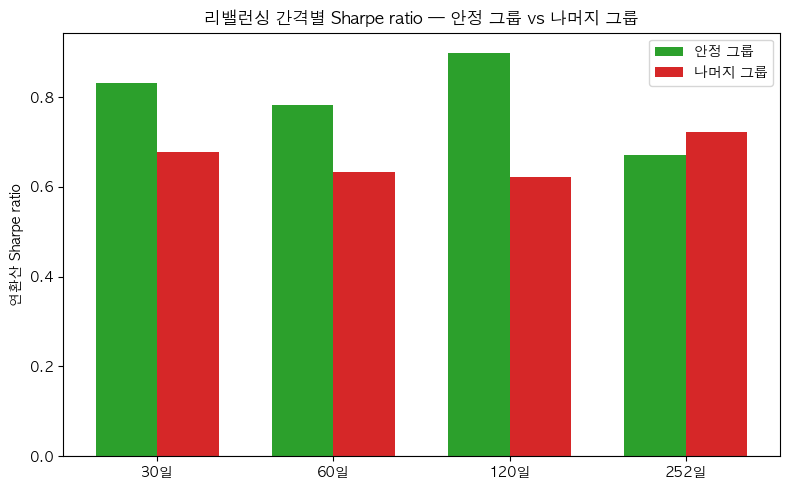

In [6]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(comparison))
width = 0.35
ax.bar(x - width / 2, comparison['안정_Sharpe'], width, label='안정 그룹', color='#2ca02c')
ax.bar(x + width / 2, comparison['나머지_Sharpe'], width, label='나머지 그룹', color='#d62728')
ax.set_xticks(x)
ax.set_xticklabels(comparison.index)
ax.set_ylabel('연환산 Sharpe ratio')
ax.set_title('리밸런싱 간격별 Sharpe ratio — 안정 그룹 vs 나머지 그룹')
ax.axhline(0, color='gray', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

## 결론 — 강건하지 않다
4개 간격 중 **안정 그룹이 이긴 건 30일·120일 두 개**, **나머지 그룹이 이긴 건 60일·252일 두 개**로 정확히 절반씩 갈린다. "안정성 우선" 전략이 리밸런싱 간격에 상관없이 일관되게 이긴다고는 말할 수 없다.

다만 이 결과는 이미 앞서 발견한 원인(시장 국면·베타 노출)과 정확히 맞아떨어진다 — 4개 간격 전부 시장수익률과 음(-)의 상관관계를 보이고(표 마지막 열), 각 간격이 하필 어떤 시장 구간을 몇 번 샘플링했는지에 따라 승패가 갈린 것이다. 252일은 표본이 9개뿐이라 특히 노이즈에 취약하다(강세장 1~2번만 껴도 결과가 크게 흔들림).

**정리**: 이 전략의 "안정 그룹이 위험 대비 수익률에서 항상 이긴다"는 주장은 데이터로 뒷받침되지 않는다. 대신 **"안정 그룹은 시장이 정체·하락할 때 상대적으로 방어력이 있고, 강세장에서는 시장 수익률을 못 따라간다"**는, 훨씬 더 정확하고 조건부인 주장이 이 프로젝트가 실제로 검증한 내용이다.